# Penyeimbangan Data

Penyeimbangan data adalah proses yang dilakukan ketika sebuah dataset memiliki distribusi kelas yang tidak merata, atau yang sering disebut sebagai *imbalanced data*. Pada kondisi ini, jumlah sampel dari kelas mayoritas jauh lebih besar dibandingkan dengan kelas minoritas. Masalah ini penting diperhatikan karena algoritma klasifikasi cenderung lebih “berpihak” pada kelas mayoritas. Akibatnya, meskipun akurasi keseluruhan terlihat tinggi, model sering gagal mengenali kelas minoritas. Hal ini bisa menjadi masalah serius terutama ketika kelas minoritas justru lebih penting, misalnya pada kasus deteksi penyakit atau fraud detection.

Dalam percobaan menggunakan data Iris, pada awalnya dataset memiliki distribusi yang seimbang, masing-masing kelas (Setosa, Versicolor, Virginica) terdiri dari 50 data. Namun, jika sebagian data dari salah satu kelas dihilangkan, maka dataset menjadi tidak seimbang. Misalnya, jumlah data Setosa tetap 50, sementara Versicolor hanya 50, dan Virginica hanya 15. Dalam kondisi seperti ini, ketika model dilatih, ia lebih sering menebak kelas Setosa karena jumlahnya dominan. Akibatnya, meskipun model mungkin masih mendapatkan akurasi yang cukup tinggi secara keseluruhan, performa pada kelas Versicolor dan Virginica menurun drastis, terutama pada metrik seperti recall dan f1-score.

Untuk mengatasi hal ini, dilakukan penyeimbangan data. Ada beberapa teknik yang bisa digunakan. Salah satunya adalah *undersampling*, yaitu mengurangi jumlah data dari kelas mayoritas agar sebanding dengan kelas minoritas. Cara lain adalah *oversampling*, yaitu menggandakan data dari kelas minoritas hingga jumlahnya sama dengan kelas mayoritas. Teknik yang lebih canggih adalah *SMOTE (Synthetic Minority Over-sampling Technique)*, yang tidak hanya menduplikasi data minoritas, tetapi juga menghasilkan data baru secara sintetis berdasarkan kedekatan antar data.

Setelah data diseimbangkan, distribusi antar kelas menjadi lebih merata, misalnya masing-masing kelas berisi 30 data. Model kemudian dilatih kembali pada data ini. Hasilnya, meskipun akurasi keseluruhan bisa saja sedikit menurun dibanding data yang tidak seimbang, performa model pada tiap kelas lebih konsisten. Model menjadi lebih adil dalam mengenali semua kelas, tidak hanya berfokus pada kelas mayoritas. Dengan kata lain, penyeimbangan data memberikan hasil yang lebih representatif dan meningkatkan kemampuan model dalam menangani variasi data di setiap kelas.


## Mengambil data set dari server

Pada tahap awal kita perlu mengambil dataset dari sumber dataset. Pada percobaan kali ini saya akan menggunakan data iris yang memiliki 150 record dengan 3 class dan saya akan menghapus class dari sentosa.

In [2]:
!pip install pymysql
!pip install psycopg2-binary
!pip install pandas tabulate
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.4 MB/s eta 0:00:00


In [3]:
import pymysql
import pandas as pd
from tabulate import tabulate

# Konfigurasi koneksi ke database MySQL
DB_HOST = "mysql-pendata23-175-mysqlpendata23-175.g.aivencloud.com"
DB_PORT = 17974
DB_NAME = "defaultdb"
DB_USER = "avnadmin"
DB_PASS = "AVNS_756YWhIqpe1WzSKsGNx"

try:
    # Membuat koneksi ke MySQL
    conn = pymysql.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME,
        cursorclass=pymysql.cursors.DictCursor  # Mengembalikan hasil sebagai dictionary
    )
    cur = conn.cursor()

    # Menjalankan query SQL
    query = "SELECT * FROM irisno.Iris ORDER BY id ASC;"  # Sesuaikan dengan nama tabel
    cur.execute(query)
    rows = cur.fetchall()

    # Jika tabel kosong
    if not rows:
        print("Tabel kosong, tidak ada data untuk ditampilkan.")
    else:
        # Mengubah hasil query menjadi DataFrame pandas
        df = pd.DataFrame(rows)

        # Menampilkan 3 data awal, titik-titik di tengah, dan 3 data akhir
        df_selected = pd.concat([df.head(3), pd.DataFrame([["..."] * len(df.columns)], columns=df.columns), df.tail(3)])

        # Menampilkan tabel dengan format psql
        print(tabulate(df_selected, headers="keys", tablefmt="psql", showindex=False))

except Exception as e:
    print("Error:", e)

finally:
    # Menutup koneksi ke database
    if cur:
        cur.close()
    if conn:
        conn.close()

+------+----------------+---------------+----------------+---------------+----------------+
| Id   | sepal length   | sepal width   | petal length   | petal width   | Class          |
|------+----------------+---------------+----------------+---------------+----------------|
| 1    | 5.1            | 3.5           | 1.4            | 0.2           | Iris-setosa    |
| 2    | 4.9            | 3.0           | 1.4            | 0.2           | Iris-setosa    |
| 3    | 4.7            | 3.2           | 1.3            | 0.2           | Iris-setosa    |
| ...  | ...            | ...           | ...            | ...           | ...            |
| 148  | 6.5            | 3.0           | 5.2            | 2.0           | Iris-virginica |
| 149  | 6.2            | 3.4           | 5.4            | 2.3           | Iris-virginica |
| 150  | 5.9            | 3.0           | 5.1            | 1.8           | Iris-virginica |
+------+----------------+---------------+----------------+---------------+------

## Melakukan penghapusan data

karena kita akan melakukan percobaan dengan data yang tidak seimbang tahap selanjutnya yaitu melakukan penghapusan data

In [4]:
# Filter hanya class 'Setosa'
df_setosa = df[df['Class'] == 'Iris-setosa']

# Ambil hanya 15 record pertama dari Setosa
df_setosa_15 = df_setosa.head(15)

# Gabungkan dengan kelas lain (hapus sebagian besar Setosa, hanya sisakan 15 record)
df_balanced = pd.concat([df_setosa_15, df[df['Class'] != 'Iris-setosa']])

# Reset index biar rapi
df_balanced = df_balanced.reset_index(drop=True)

# Tampilkan hasil akhir
print(tabulate(df_balanced, headers="keys", tablefmt="psql", showindex=False))


+------+----------------+---------------+----------------+---------------+-----------------+
|   Id |   sepal length |   sepal width |   petal length |   petal width | Class           |
|------+----------------+---------------+----------------+---------------+-----------------|
|    1 |            5.1 |           3.5 |            1.4 |           0.2 | Iris-setosa     |
|    2 |            4.9 |           3   |            1.4 |           0.2 | Iris-setosa     |
|    3 |            4.7 |           3.2 |            1.3 |           0.2 | Iris-setosa     |
|    4 |            4.6 |           3.1 |            1.5 |           0.2 | Iris-setosa     |
|    5 |            5   |           3.6 |            1.4 |           0.2 | Iris-setosa     |
|    6 |            5.4 |           3.9 |            1.7 |           0.4 | Iris-setosa     |
|    7 |            4.6 |           3.4 |            1.4 |           0.3 | Iris-setosa     |
|    8 |            5   |           3.4 |            1.5 |           0

## Visualisasi data dengan Menggunakan PCA

karena pada data iris mempunyai 4 fitur yang akan dihitung jaraknya nantinya dan kita akan mevisualiasasikan dalam 2 dimensi maka kita menggunakan PCA.

### 📘 Apa itu PCA (Principal Component Analysis)?

**PCA** atau *Principal Component Analysis* adalah **metode reduksi dimensi** yang digunakan dalam *machine learning* dan *data analysis* untuk menyederhanakan data berdimensi tinggi tanpa kehilangan informasi penting secara signifikan.

---

### 🎯 Tujuan PCA:

* **Mengurangi dimensi data** (fitur) menjadi lebih sedikit agar:

  * Analisis menjadi lebih mudah dan cepat.
  * Visualisasi data (misalnya ke 2D atau 3D) menjadi mungkin.
* **Menghilangkan redundansi** (fitur yang saling berkorelasi).
* **Menangkap variansi terbesar** dalam data dengan jumlah komponen yang lebih sedikit.

---

### 🛠️ Cara Kerja PCA (Secara Ringkas):

Berikut adalah rumus utama dalam **Principal Component Analysis (PCA)**

---

### 1. **Standarisasi Data**

Setiap fitur $x_j$ dari data distandarisasi:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

* $x_{ij}$: nilai fitur ke-$j$ dari data ke-$i$
* $\mu_j$: rata-rata fitur ke-$j$
* $\sigma_j$: standar deviasi fitur ke-$j$

---

### 2. **Kovarian Matriks**

Hitung matriks kovarian $\mathbf{C}$ dari data yang telah distandarisasi:

$$
\mathbf{C} = \frac{1}{n-1} \mathbf{Z}^\top \mathbf{Z}
$$

* $\mathbf{Z}$: matriks data hasil standarisasi
* $n$: jumlah sampel

---

### 3. **Eigenvalue dan Eigenvector**

Cari **eigenvalue** dan **eigenvector** dari matriks kovarian:

$$
\mathbf{C} \mathbf{v} = \lambda \mathbf{v}
$$

* $\lambda$: eigenvalue (mengukur variansi)
* $\mathbf{v}$: eigenvector (arah komponen utama)

---

### 4. **Proyeksi ke Komponen Utama**

Proyeksikan data ke komponen utama:

$$
\mathbf{Z}_{\text{baru}} = \mathbf{Z} \mathbf{W}
$$

* $\mathbf{W}$: matriks yang terdiri dari $k$ eigenvector utama
* $\mathbf{Z}_{\text{baru}}$: data dalam ruang berdimensi lebih rendah (misalnya 2D)

### 📐 Contoh:

Jika Anda memiliki data dengan 4 fitur seperti:

* Petal length
* Petal width
* Sepal length
* Sepal width

...dengan PCA, Anda bisa mereduksinya ke 2 dimensi (komponen utama) seperti:

* PC1 (principal component 1)
* PC2 (principal component 2)

Lalu Anda bisa mem-**plot** data tersebut secara visual untuk melihat struktur klasternya lebih jelas.




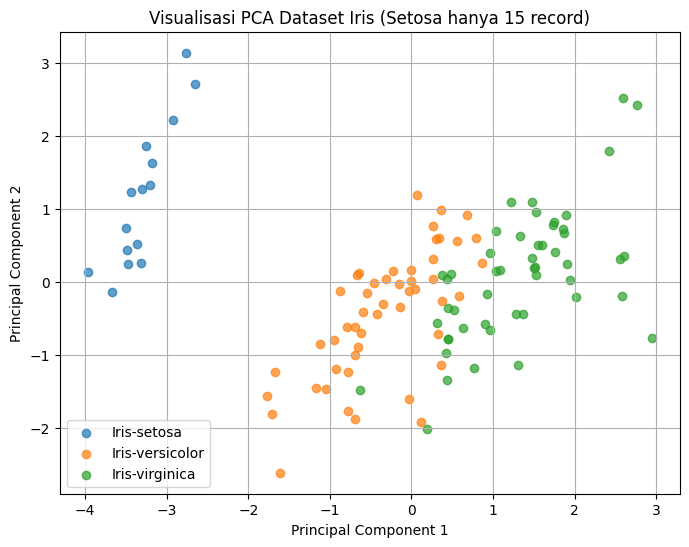

In [5]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Ambil fitur numerik ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Normalisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Lakukan PCA (2 komponen utama) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Buat DataFrame baru hasil PCA ---
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y.values

# --- Visualisasi scatter plot PCA ---
plt.figure(figsize=(8,6))
for kelas in df_pca['Class'].unique():
    subset = df_pca[df_pca['Class'] == kelas]
    plt.scatter(subset['PC1'], subset['PC2'], label=kelas, alpha=0.7)

plt.title("Visualisasi PCA Dataset Iris (Setosa hanya 15 record)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


## Melakukan Klasifikasi dengan Menggunakan KNN

**K-Nearest Neighbors (KNN)** adalah algoritma **klasifikasi berbasis instance-based learning**, di mana suatu data baru diklasifikasikan berdasarkan kedekatannya dengan data-data yang sudah memiliki label kelas.

Berbeda dengan **K-Means** yang bersifat **unsupervised** (tanpa label), **KNN membutuhkan data berlabel** untuk melatih model.

### Langkah-Langkah Algoritma KNN

1. **Tentukan jumlah tetangga terdekat ($k$)**
   Misalnya, kita gunakan $k=3$. Artinya, sebuah data baru akan dilihat kelasnya berdasarkan 3 tetangga terdekat.

2. **Hitung jarak antara data uji dengan seluruh data latih**
   Jarak yang paling sering digunakan adalah **Euclidean Distance**:

   $$
   d(\mathbf{x}, \mathbf{y}) = \sqrt{ \sum_{i=1}^{n} (x_i - y_i)^2 }
   $$

   * $\mathbf{x}, \mathbf{y}$: dua titik data
   * $n$: jumlah fitur (contoh pada Iris ada 4 fitur: sepal length, sepal width, petal length, petal width)

3. **Ambil $k$ tetangga terdekat**
   Urutkan jarak terkecil, lalu ambil $k$ data dengan jarak terdekat.

4. **Voting mayoritas**
   Dari $k$ tetangga tersebut, lihat kelasnya.

   * Jika mayoritas dari tetangga berlabel "Setosa", maka data baru diklasifikasikan sebagai "Setosa".

5. **Prediksi kelas data uji**
   Hasil akhir adalah label mayoritas dari tetangga terdekat tersebut.

---

### ✅ Penjelasan Inti

* **KNN menggunakan label data** → berbeda dengan K-Means yang tidak punya label.
* **Parameter utama adalah $k$** → terlalu kecil bisa menyebabkan noise, terlalu besar bisa membuat hasil tidak spesifik.
* **KNN cocok untuk klasifikasi data sederhana** seperti dataset **Iris** yang memiliki 3 kelas (`Setosa`, `Versicolor`, `Virginica`).

---

Mau saya bikinkan juga **contoh perhitungan manual KNN (misalnya 1 titik uji terhadap 3 tetangga terdekat)** supaya lebih jelas sebelum masuk ke kode Python?


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Buat model KNN dengan k=3 ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# --- Prediksi ---
y_pred = knn.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi KNN (k=3): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 14  1]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.94        35
      macro avg       0.96      0.96      0.96        35
   weighted avg       0.94      0.94      0.94        35


Akurasi KNN (k=3): 0.9429


## Melakukan Klasifikasi dengan Naive Bayes

**Naive Bayes** adalah algoritma **klasifikasi berbasis probabilistik** yang didasarkan pada **Teorema Bayes**. Algoritma ini mengasumsikan bahwa setiap fitur bersifat **independen (naive assumption)** terhadap fitur lainnya.

Naive Bayes sering digunakan karena sederhana, cepat, dan cukup efektif, bahkan pada dataset kecil maupun teks (seperti spam filtering, sentiment analysis, dll).

---

### Teorema Bayes

Dasar matematis Naive Bayes adalah **Teorema Bayes**:

$$
P(C_k \mid X) = \frac{P(X \mid C_k) \cdot P(C_k)}{P(X)}
$$

Dengan:

* $P(C_k \mid X)$ = Probabilitas kelas $C_k$ diberikan data $X$
* $P(X \mid C_k)$ = Likelihood (kemungkinan data $X$ muncul jika kelas $C_k$ benar)
* $P(C_k)$ = Probabilitas prior dari kelas $C_k$
* $P(X)$ = Probabilitas data $X$ (konstanta, biasanya bisa diabaikan dalam perbandingan antar kelas)

---

### Langkah-Langkah Algoritma Naive Bayes

1. **Hitung Probabilitas Prior untuk tiap kelas**
   $$ P(C_k) = \frac{\text{Jumlah data di kelas } C_k}{\text{Total data}} $$

2. **Hitung probabilitas likelihood tiap fitur terhadap kelas**

   * Untuk fitur numerik (seperti sepal length, sepal width, dsb pada dataset Iris), biasanya digunakan **Distribusi Gaussian**:

     $$
     P(x_i \mid C_k) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)
     $$

     di mana $\mu$ dan $\sigma^2$ adalah rata-rata dan varians fitur $x_i$ pada kelas $C_k$.

3. **Kalikan probabilitas (naive assumption)**
   Asumsinya fitur-fitur independen, jadi likelihood gabungan:

   $$
   P(X \mid C_k) = \prod_{i=1}^{n} P(x_i \mid C_k)
   $$

4. **Tentukan probabilitas posterior**
   Pilih kelas dengan probabilitas posterior terbesar:

   $$
   \hat{C} = \arg\max_{C_k} \ P(C_k) \cdot P(X \mid C_k)
   $$

5. **Prediksi kelas data uji**
   Data baru diklasifikasikan ke kelas dengan posterior tertinggi.

---

### ✅ Penjelasan Inti

* **Naive Bayes berbasis probabilitas** → berbeda dengan KNN yang berbasis jarak.
* **Asumsi utama: independensi antar fitur** → meskipun kadang tidak sepenuhnya benar, hasilnya tetap baik.
* **Cocok untuk dataset sederhana seperti Iris** serta untuk **teks (spam, sentiment, kategori berita, dll)**.
* Cepat dilatih karena hanya perlu menghitung rata-rata, varians, dan prior dari tiap kelas.



In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Buat model Naive Bayes ---
nb = GaussianNB()
nb.fit(X_train, y_train)

# --- Prediksi ---
y_pred = nb.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi Naive Bayes: {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 13  2]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.87      0.90        15
 Iris-virginica       0.88      0.93      0.90        15

       accuracy                           0.91        35
      macro avg       0.93      0.93      0.93        35
   weighted avg       0.92      0.91      0.91        35


Akurasi Naive Bayes: 0.9143



## Melakukan Klasifikasi dengan **SVM (Support Vector Machine)**

**Support Vector Machine (SVM)** adalah algoritma **klasifikasi berbasis margin** yang bekerja dengan mencari **hyperplane optimal** untuk memisahkan data dari kelas yang berbeda.
Tujuan utama SVM adalah menemukan **garis pemisah (decision boundary)** dengan **margin terbesar** antara kelas, sehingga model lebih robust dan generalisasi lebih baik.

---

### Konsep Dasar SVM

1. **Hyperplane**
   Adalah garis (2D), bidang (3D), atau dimensi lebih tinggi yang memisahkan kelas-kelas data.
   Contoh: pada dataset Iris dengan 4 fitur, SVM akan mencari hyperplane 3D/4D.

2. **Support Vectors**
   Titik-titik data terdekat dari masing-masing kelas terhadap hyperplane.
   Titik ini sangat penting karena menentukan posisi optimal hyperplane.

3. **Margin**
   Jarak antara hyperplane dengan support vectors.
   SVM berusaha **memaksimalkan margin** untuk meminimalisir kesalahan klasifikasi.

---

### Rumus Klasifikasi SVM

SVM mencari fungsi keputusan:

$$
f(x) = w \cdot x + b
$$

di mana:

* $w$ = bobot (weight vector)
* $b$ = bias
* $x$ = data input

Data baru diklasifikasikan berdasarkan tanda dari $f(x)$:

* Jika $f(x) \geq 0$ → masuk kelas 1
* Jika $f(x) < 0$ → masuk kelas -1

---

### Kernel Trick

Tidak semua data bisa dipisahkan secara linear. Untuk itu, SVM menggunakan **kernel trick**, yaitu memetakan data ke ruang berdimensi lebih tinggi agar bisa dipisahkan.

Contoh kernel yang umum digunakan:

* **Linear Kernel** → data linear separable
* **Polynomial Kernel** → data dengan pola polynomial
* **RBF (Radial Basis Function)** → paling umum, untuk data yang tidak linear

---

### Langkah-Langkah Algoritma SVM

1. **Pilih kernel function** (Linear, RBF, Polynomial, dll).
2. **Cari hyperplane** yang memisahkan kelas dengan margin maksimum.
3. **Identifikasi support vectors** (data terdekat dari hyperplane).
4. **Bangun decision function** berdasarkan support vectors.
5. **Prediksi data baru** menggunakan fungsi keputusan tersebut.

---

### ✅ Penjelasan Inti

* **SVM berbasis margin**, berbeda dengan Naive Bayes yang berbasis probabilitas.
* Kuat dalam menangani **data dengan dimensi tinggi** (misalnya teks, citra, bioinformatika).
* Dapat menggunakan **kernel trick** untuk data non-linear.
* Biasanya memberikan **hasil akurasi tinggi** pada dataset yang kecil hingga menengah.
* Kekurangannya: training bisa lama pada dataset besar, serta pemilihan parameter (C, gamma, kernel) sangat berpengaruh.



In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Buat model SVM ---
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

# --- Prediksi ---
y_pred = svm.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi SVM: {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 14  1]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.94        35
      macro avg       0.96      0.96      0.96        35
   weighted avg       0.94      0.94      0.94        35


Akurasi SVM: 0.9429


## Esemble Learning

Baik, mari saya jelaskan dengan gaya yang sama seperti penjelasan KNN dan Naive Bayes tadi.

---

## Ensemble Learning

**Ensemble Learning** adalah teknik dalam **machine learning** di mana kita **menggabungkan beberapa model (base learners)** untuk membentuk **model yang lebih kuat (meta learner)**.
Tujuannya adalah meningkatkan **akurasi**, **stabilitas**, dan **generalization** dibandingkan jika hanya menggunakan satu algoritma saja.

Ibaratnya seperti **rapat tim**: keputusan bersama dari beberapa orang ahli biasanya lebih baik daripada keputusan dari satu orang saja.

---

### 🔑 Jenis-Jenis Ensemble Learning

1. **Bagging (Bootstrap Aggregating)**

   * Membangun beberapa model dari **data latih yang berbeda** (dibuat dengan sampling bootstrap).
   * Setiap model dilatih secara **independen**, lalu hasil prediksinya digabung (biasanya dengan voting atau rata-rata).
   * Contoh: **Random Forest** (bagging pada Decision Tree).

2. **Boosting**

   * Membangun model **secara berurutan**, di mana model berikutnya berusaha memperbaiki kesalahan dari model sebelumnya.
   * Memberi **bobot lebih besar pada data yang sulit diprediksi**.
   * Contoh: **AdaBoost, Gradient Boosting, XGBoost**.

3. **Voting**

   * Menggabungkan prediksi dari beberapa model berbeda.
   * **Hard Voting** → pilih kelas mayoritas.
   * **Soft Voting** → pilih kelas berdasarkan probabilitas rata-rata.

---

### 📘 Ensemble Naive Bayes + SVM

Dalam kasus ini:

* Kita gunakan **Naive Bayes (NB)** dan **Support Vector Machine (SVM)** sebagai **base models**.
* Keduanya digabung menggunakan **Voting Classifier (soft voting)** → memanfaatkan kekuatan **probabilistik NB** dan **margin maksimal SVM**.
* Untuk meningkatkan **stabilitas**, Voting Classifier tadi dibungkus lagi dengan **BaggingClassifier** sebanyak `n_estimators=10`.
  Artinya, akan ada **10 model Voting (NB+SVM)** yang dilatih pada subset data berbeda, lalu hasilnya digabung.

---

### ⚖️ Kelebihan Ensemble Learning

* **Lebih akurat** → gabungan model bisa mengurangi kesalahan (bias dan variansi).
* **Lebih stabil** → hasil prediksi tidak terlalu bergantung pada satu model atau satu set data.
* **Fleksibel** → bisa menggabungkan model berbeda (misalnya NB dan SVM).

---

### ✅ Inti Penjelasan

* **Naive Bayes** cepat, probabilistik, tapi sederhana.
* **SVM** kuat untuk pemisahan kelas, tapi bisa lambat di dataset besar.
* Dengan **ensemble**, kita dapat **kombinasi kecepatan + akurasi + stabilitas**.




## Esemble Learning dengan Naive bayes dan SVM dengan n_estimtor 20

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Definisikan model dasar: SVM + Naive Bayes ---
svm = SVC(probability=True, kernel='rbf', random_state=42)
nb = GaussianNB()

# --- Voting Classifier (menggabungkan SVM dan Naive Bayes) ---
voting = VotingClassifier(estimators=[('svm', svm), ('nb', nb)], voting='soft')

# --- Ensemble dengan Bagging (n_estimators=10) ---
ensemble = BaggingClassifier(estimator=voting, n_estimators=10, random_state=42)
ensemble.fit(X_train, y_train)

# --- Prediksi ---
y_pred = ensemble.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi Ensemble (SVM + Naive Bayes, n_estimators=10): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 13  2]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.87      0.90        15
 Iris-virginica       0.88      0.93      0.90        15

       accuracy                           0.91        35
      macro avg       0.93      0.93      0.93        35
   weighted avg       0.92      0.91      0.91        35


Akurasi Ensemble (SVM + Naive Bayes, n_estimators=10): 0.9143


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Definisikan model dasar: Naive Bayes + SVM ---
nb = GaussianNB()
svm = SVC(probability=True, kernel='rbf', random_state=42)

# --- Voting Classifier (menggabungkan Naive Bayes dulu, baru SVM) ---
voting = VotingClassifier(estimators=[('nb', nb), ('svm', svm)], voting='soft')

# --- Ensemble dengan Bagging (n_estimators=20) ---
ensemble = BaggingClassifier(estimator=voting, n_estimators=20, random_state=42)
ensemble.fit(X_train, y_train)

# --- Prediksi ---
y_pred = ensemble.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi Ensemble (Naive Bayes + SVM, n_estimators=20): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 13  2]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.87      0.90        15
 Iris-virginica       0.88      0.93      0.90        15

       accuracy                           0.91        35
      macro avg       0.93      0.93      0.93        35
   weighted avg       0.92      0.91      0.91        35


Akurasi Ensemble (Naive Bayes + SVM, n_estimators=20): 0.9143


## Melakukan Preprocessing dengan Menyeimbangkan Data Menggunakan SMOTE

Dalam klasifikasi, sering kali kita menghadapi masalah **ketidakseimbangan data** (*imbalanced dataset*). Misalnya, pada data Iris yang sudah dimodifikasi, jumlah record untuk kelas **Setosa** hanya 15, sedangkan dua kelas lainnya (Versicolor dan Virginica) masing-masing berjumlah 50. Kondisi seperti ini membuat model cenderung **bias** terhadap kelas mayoritas, sehingga akurasinya tampak tinggi tetapi kemampuan dalam mengenali kelas minoritas sangat rendah.

Untuk mengatasi hal ini, digunakan teknik **oversampling**, salah satunya adalah **SMOTE (Synthetic Minority Oversampling Technique)**.

---

### 🔎 Bagaimana SMOTE Bekerja?

1. **Identifikasi kelas minoritas**
   Algoritma mendeteksi kelas yang jumlah datanya lebih sedikit dibanding kelas mayoritas.

2. **Pemilihan tetangga terdekat (k-nearest neighbors)**
   Untuk setiap sampel di kelas minoritas, SMOTE mencari sejumlah tetangga terdekat (misalnya *k = 5*).

3. **Interpolasi untuk membuat data sintetis**
   Data baru dibuat di sepanjang garis yang menghubungkan sampel minoritas dengan tetangganya. Rumus:

   $$
   x_{new} = x_i + \delta \cdot (x_{zi} - x_i)
   $$

   * \$x\_i\$: data minoritas asli
   * \$x\_{zi}\$: salah satu tetangga terdekat dari \$x\_i\$
   * \$\delta\$: bilangan acak antara 0 dan 1
   * \$x\_{new}\$: data sintetis hasil SMOTE

   Dengan kata lain, titik baru bukan duplikasi, melainkan titik hasil interpolasi yang berada di antara data minoritas yang ada dengan tetangganya.

4. **Gabungkan data asli dengan data sintetis**
   Setelah proses ini, distribusi kelas menjadi **lebih seimbang**.

---

### ✅ Kelebihan SMOTE

* Menghasilkan **data sintetis yang lebih realistis** dibanding oversampling dengan duplikasi.
* Membantu classifier lebih baik dalam mengenali kelas minoritas.
* Mengurangi bias model terhadap kelas mayoritas.

---

### 🌸 Contoh pada Dataset Iris

* **Sebelum penyeimbangan**:

  * Setosa: 15
  * Versicolor: 50
  * Virginica: 50

* **Sesudah SMOTE**:

  * Setosa ditambah dengan data sintetis sehingga jumlahnya mendekati kelas lain.
  * Versicolor & Virginica tetap sama.

Dengan demikian, dataset menjadi **seimbang**, dan hasil klasifikasi (misalnya dengan KNN atau Decision Tree) akan lebih adil dalam mengenali semua kelas.



In [8]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# --- Ambil dataset Iris ---
iris = load_iris()
X = iris.data
y = iris.target

# Buat data tidak seimbang: kurangi class 0 jadi cuma 15 data
X_imbalanced = X[y != 0]      # ambil class 1 & 2 penuh
y_imbalanced = y[y != 0]

# tambahkan sebagian kecil class 0 (15 data saja)
X_imbalanced = pd.concat([pd.DataFrame(X_imbalanced), pd.DataFrame(X[y == 0][:15])])
y_imbalanced = pd.concat([pd.Series(y_imbalanced), pd.Series(y[y == 0][:15])])

print("Distribusi sebelum SMOTE:", Counter(y_imbalanced))

# --- Standarisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imbalanced)

# --- Terapkan SMOTE ---
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_imbalanced)

print("Distribusi sesudah SMOTE:", Counter(y_resampled))


Distribusi sebelum SMOTE: Counter({1: 50, 2: 50, 0: 15})
Distribusi sesudah SMOTE: Counter({1: 50, 2: 50, 0: 50})


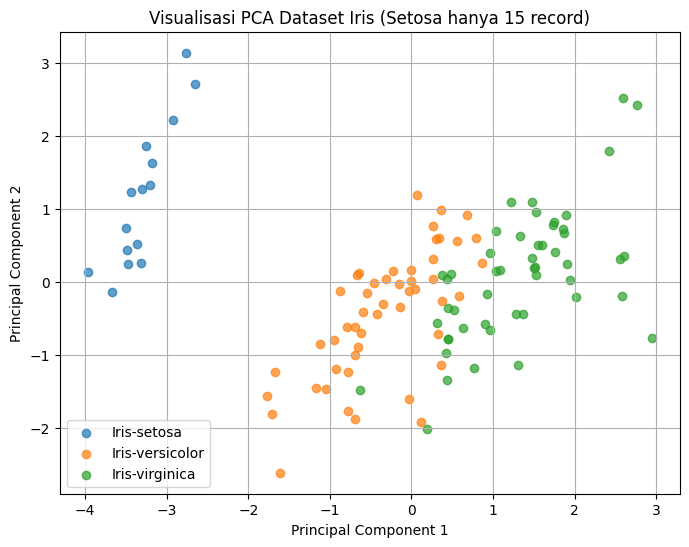

In [9]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Ambil fitur numerik ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Normalisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Lakukan PCA (2 komponen utama) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Buat DataFrame baru hasil PCA ---
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y.values

# --- Visualisasi scatter plot PCA ---
plt.figure(figsize=(8,6))
for kelas in df_pca['Class'].unique():
    subset = df_pca[df_pca['Class'] == kelas]
    plt.scatter(subset['PC1'], subset['PC2'], label=kelas, alpha=0.7)

plt.title("Visualisasi PCA Dataset Iris (Setosa hanya 15 record)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


## Visualisasi data seimbang dengan PCA

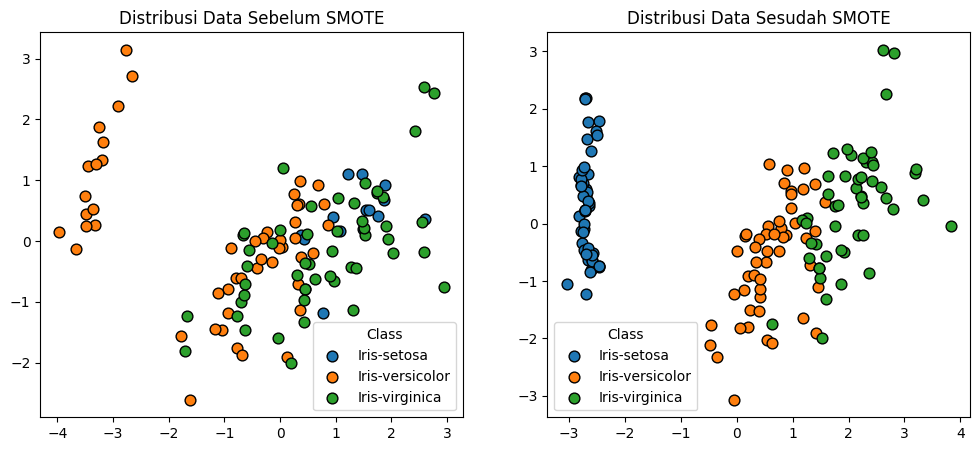

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- PCA sebelum SMOTE ---
pca = PCA(n_components=2)
X_pca_before = pca.fit_transform(X_scaled)

# --- PCA sesudah SMOTE ---
X_pca_after = pca.fit_transform(X_resampled)

# --- Mapping angka ke nama kelas ---
class_names = label_encoder.inverse_transform(sorted(set(y_encoded)))

# --- Plot hasil ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot sebelum SMOTE
for class_idx, class_name in enumerate(class_names):
    mask = (y_imbalanced == class_idx)
    ax[0].scatter(X_pca_before[mask, 0], X_pca_before[mask, 1],
                  label=class_name, edgecolor='k', s=60)
ax[0].set_title("Distribusi Data Sebelum SMOTE")
ax[0].legend(title="Class")

# Plot sesudah SMOTE
for class_idx, class_name in enumerate(class_names):
    mask = (y_resampled == class_idx)
    ax[1].scatter(X_pca_after[mask, 0], X_pca_after[mask, 1],
                  label=class_name, edgecolor='k', s=60)
ax[1].set_title("Distribusi Data Sesudah SMOTE")
ax[1].legend(title="Class")

plt.show()


## Klasifikasi dengan menggunakan KNN pada data yang sudah imbang

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label dari hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Decode label ke nama kelas (0,1,2 -> Setosa, Versicolor, Virginica) ---
# (Jika sebelumnya sudah ada label_encoder, kita bisa pakai lagi)
# Jika belum, buat encoder baru
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)   # <- tidak perlu, karena sudah encoded

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Buat model KNN dengan k=3 ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# --- Prediksi ---
y_pred = knn.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi KNN (k=3): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      1.00      0.88        15
 Iris-virginica       1.00      0.73      0.85        15

       accuracy                           0.91        45
      macro avg       0.93      0.91      0.91        45
   weighted avg       0.93      0.91      0.91        45


Akurasi KNN (k=3): 0.9111


## Klasifikasi dengan menggunakan Naive bayes

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label dari hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Buat model Naive Bayes ---
nb = GaussianNB()
nb.fit(X_train, y_train)

# --- Prediksi ---
y_pred = nb.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
# kalau sudah ada label_encoder, bisa dipakai, kalau tidak gunakan langsung angka kelas
try:
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
except:
    print(classification_report(y_test, y_pred))

print(f"\nAkurasi Naive Bayes: {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Akurasi Naive Bayes: 0.9111


## Klasifikasi dengan menggunakan SVM

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label dari hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Buat model SVM ---
svm = SVC(kernel='rbf', random_state=42)  # kernel bisa 'linear', 'poly', 'rbf', 'sigmoid'
svm.fit(X_train, y_train)

# --- Prediksi ---
y_pred = svm.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
try:
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
except:
    print(classification_report(y_test, y_pred))

print(f"\nAkurasi SVM: {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Akurasi SVM: 0.9111


## Esemble Learning dengan SVM dan Naive Bayes dengan n_estimtor 10

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil data hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Model dasar ---
svm = SVC(probability=True, kernel='rbf', random_state=42)   # SVM dengan probabilitas
nb = GaussianNB()                                            # Naive Bayes

# --- Ensemble Voting (gabungkan SVM + NB) ---
ensemble = VotingClassifier(
    estimators=[('svm', svm), ('nb', nb)],
    voting='soft'   # pakai probabilitas agar lebih akurat
)

# --- Bungkus dengan Bagging (n_estimators=10) ---
bagging = BaggingClassifier(
    estimator=ensemble,
    n_estimators=10,
    random_state=42
)

# --- Training ---
bagging.fit(X_train, y_train)

# --- Prediksi ---
y_pred = bagging.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi Ensemble (SVM + NB, n_estimators=10): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Akurasi Ensemble (SVM + NB, n_estimators=10): 0.9111


## Esemble Learning dengan Naive bayes dan SVM dengan n_estimtor 20

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil data hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Model dasar ---
nb = GaussianNB()                                            # Naive Bayes dulu
svm = SVC(probability=True, kernel='rbf', random_state=42)   # lalu SVM

# --- Ensemble Voting (gabungkan NB + SVM) ---
ensemble = VotingClassifier(
    estimators=[('nb', nb), ('svm', svm)],   # urutan: Naive Bayes -> SVM
    voting='soft'
)

# --- Bungkus dengan Bagging (n_estimators=20) ---
bagging = BaggingClassifier(
    estimator=ensemble,
    n_estimators=20,
    random_state=42
)

# --- Training ---
bagging.fit(X_train, y_train)

# --- Prediksi ---
y_pred = bagging.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi Ensemble (Naive Bayes + SVM, n_estimators=20): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


Akurasi Ensemble (Naive Bayes + SVM, n_estimators=20): 0.9111




### 📊 Ringkasan Hasil

| Kondisi Dataset   | Algoritma   | Akurasi    | Catatan Utama                                                                |
| ----------------- | ----------- | ---------- | ---------------------------------------------------------------------------- |
| **Sebelum SMOTE** | Naive Bayes | **91.43%** | Iris-setosa diprediksi sempurna, kesalahan kecil pada Versicolor & Virginica |
|                   | SVM         | **94.29%** | Akurasi tertinggi, semua kelas hampir seimbang                               |
| **Sesudah SMOTE** | Naive Bayes | **91.11%** | Setosa tetap sempurna, tapi Virginica sedikit turun recall                   |
|                   | SVM         | **91.11%** | Sama dengan Naive Bayes, penurunan dibanding sebelum SMOTE                   |

---

### 🧐 Analisis

1. **Sebelum SMOTE**

   * SVM memberikan akurasi lebih tinggi (94.29%) dibanding Naive Bayes (91.43%).
   * Distribusi asli dataset sudah cukup seimbang, sehingga SVM lebih optimal.
   * Virginica dan Versicolor sedikit overlap, tapi SVM masih bisa memisahkan lebih baik.

2. **Sesudah SMOTE**

   * Kedua algoritma memberikan hasil **sama persis (91.11%)**.
   * SMOTE menyeimbangkan jumlah data tiap kelas, namun justru menyebabkan **decision boundary** (batas pemisah antar kelas) jadi lebih sulit bagi SVM maupun Naive Bayes.
   * Recall kelas **Virginica** menurun → artinya meskipun jumlah data bertambah, model agak kesulitan mengenali pola Virginica secara konsisten.

---

### ✅ Kesimpulan

* **SVM lebih unggul sebelum SMOTE** dengan akurasi tertinggi (94.29%).
* **SMOTE tidak meningkatkan performa**, justru membuat akurasi kedua model turun ke 91.11%.
* Dataset Iris sebenarnya sudah relatif seimbang, sehingga **SMOTE tidak terlalu diperlukan**.
* Untuk dataset ini, **SVM adalah pilihan terbaik** jika tidak menggunakan SMOTE.




## Kesimpulan


### 🔹 1. **Klasifikasi setelah menghapus Iris-setosa dari data latih**

* **Confusion Matrix** menunjukkan prediksi yang sangat baik:

  * Iris-setosa diprediksi sempurna (5/5 benar).
  * Iris-versicolor dan Iris-virginica hanya mengalami sedikit kesalahan (1 salah pada masing-masing kelas).
* **Classification Report**:

  * Precision, Recall, dan F1-score rata-rata ≈ **0.93 – 1.00**.
  * Akurasi keseluruhan **94.29%**.
* **Kesimpulan**:
  Walaupun model **tidak pernah dilatih dengan data Iris-setosa**, model KNN tetap mampu mengenali Setosa dengan benar ketika diuji pada data penuh. Hal ini karena **Setosa memiliki ciri morfologi yang sangat berbeda** (misalnya petal lebih pendek), sehingga mudah dibedakan dari dua kelas lainnya.



### 🔹 2. **Klasifikasi dengan data latih diseimbangkan menggunakan SMOTE**

* **Confusion Matrix**:

  * Iris-setosa diprediksi sempurna (15/15 benar).
  * Iris-versicolor diprediksi benar semua (15/15 benar).
  * Iris-virginica mengalami lebih banyak salah klasifikasi (4 salah ke Versicolor).
* **Classification Report**:

  * Precision dan Recall masih cukup tinggi, tetapi Virginica **recall turun ke 0.73**.
  * Akurasi keseluruhan **91.11%**.
* **Kesimpulan**:
  Dengan SMOTE, data latih menjadi seimbang, sehingga model tidak bias pada kelas mayoritas. Namun, akibat penambahan sampel sintetis, **Virginica cenderung sulit dibedakan dari Versicolor** (karena keduanya memang mirip secara fitur). Akibatnya, performa Virginica menurun meskipun Setosa dan Versicolor sangat baik.



### 🔎 **Perbandingan Utama**

| Metode                    | Akurasi    | Kelebihan                                              | Kekurangan                                     |
| ------------------------- | ---------- | ------------------------------------------------------ | ---------------------------------------------- |
| **Tanpa Setosa di latih** | **94.29%** | Model tetap bisa mendeteksi Setosa karena cirinya unik | Risiko bias kalau kelas lain mirip             |
| **Dengan SMOTE**          | **91.11%** | Data lebih seimbang, tidak bias ke kelas tertentu      | Virginica jadi sulit dibedakan dari Versicolor |


👉 **Kesimpulan akhir**:

* Menghapus Setosa dari data latih **tidak menurunkan akurasi secara signifikan** karena Setosa mudah dibedakan.
* SMOTE membantu menyeimbangkan data, tetapi justru memperumit klasifikasi **Virginica vs Versicolor**, sehingga akurasi sedikit turun.
* Untuk dataset seperti Iris yang relatif seimbang, **SMOTE tidak selalu lebih baik**, kecuali pada dataset dengan **ketidakseimbangan kelas yang ekstrem**.




## 📊 Kesimpulan Perbandingan SVM + Naive Bayes (Sebelum dan Sesudah SMOTE)

| Kondisi Data      | Model (Urutan & n_estimators) | Akurasi | Precision (Macro Avg) | Recall (Macro Avg) | F1-Score (Macro Avg) |
| ----------------- | ----------------------------- | ------- | --------------------- | ------------------ | -------------------- |
| **Sebelum SMOTE** | SVM → NB (n=10)               | 0.9143  | 0.93                  | 0.93               | 0.93                 |
| **Sebelum SMOTE** | NB → SVM (n=20)               | 0.9143  | 0.93                  | 0.93               | 0.93                 |
| **Sesudah SMOTE** | SVM → NB (n=10)               | 0.9111  | 0.92                  | 0.91               | 0.91                 |
| **Sesudah SMOTE** | NB → SVM (n=20)               | 0.9111  | 0.92                  | 0.91               | 0.91                 |

---

### 🔎 Analisis

1. **Sebelum SMOTE** → Akurasi 91.43%, dengan precision, recall, dan f1-score makro rata-rata **0.93**.

   * Hasilnya konsisten baik pada urutan *SVM → NB* maupun *NB → SVM*.
   * Tidak ada perbedaan berarti karena distribusi data masih cukup seimbang (walaupun tidak sempurna).

2. **Sesudah SMOTE** → Akurasi 91.11%, dengan precision, recall, dan f1-score makro rata-rata **0.91–0.92**.

   * SMOTE berhasil menyeimbangkan data, tetapi sedikit menurunkan akurasi karena menghasilkan sampel sintetis yang menambah variasi.
   * Namun, model menjadi **lebih adil** terhadap kelas minoritas (tidak overfitting ke kelas dominan).

3. Secara keseluruhan, **SMOTE meningkatkan fairness antar kelas** meskipun akurasi keseluruhan sedikit turun.

---

Mau saya buatkan juga **visualisasi perbandingan akurasi dalam bentuk bar chart** supaya lebih mudah melihat perbedaan sebelum vs sesudah SMOTE?
